# Notebook 2: Stage 1 Training (Flat-State FiLM, Shot 1)

Trains the shot-1 FiLM world model on pre-computed Qwen3-4B **single-vector** date embeddings from Notebook 1.

**Architecture note**: this notebook uses the **flat-state** variant. The `(10, 46)` lookback window is flattened to `(460,)` and embedded by a 2-layer MLP, so cross-day and cross-feature interactions are captured directly in the state embedding. With no sequence axis to reason over, the cross-attention and temporal transformer from the original design are removed — the architecture is now just `MarketStateMLP → FiLM_anchor → FiLM_event → PredictionHead`. See `FiLM_alternative_architecture.md` for the deferred stateful-FiLM variant and `20260411_architecture_discussion.md` for the discussion that led here.

- **Input**: `event_embeddings.pt` (one pooled vector per date), `combined_commodity_data.csv`
- **Output**: `stage1_best.pt`

In [16]:
import os
import math
from bisect import bisect_left, bisect_right
from dataclasses import dataclass

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cpu


## Config

In [17]:
@dataclass
class Config:
    # Data paths (Kaggle)
    data_dir: str = "/kaggle/input/datasets/zygong1994/finance-world-model-dataset"
    embeddings_path: str = "/kaggle/input/notebooks/zygong1994/world-model-v1-step1-embedding/event_embeddings.pt"

    # Architecture (flat-state variant)
    n_features: int = 46
    d_model: int = 256
    state_mlp_hidden: int = 512      # width of the first MLP layer on the flat state
    lookback: int = 10
    horizon: int = 10
    dropout: float = 0.1

    # Qwen embedding dim (must match precomputed embeddings)
    qwen_hidden: int = 2560
    # Max date vectors in a lookback window (one per date with valid cache entry)
    max_events_per_window: int = 8

    # Critical features for loss
    critical_features: tuple = (
        "YF_Price_Crude Oil (WTI)",
        "YF_Price_Crude Oil (Brent)",
        "YF_Price_Gold",
        "YF_Price_Natural Gas",
        "YF_Price_Silver",
        "YF_Price_Copper",
    )

    # Features that should use a first difference instead of a log return.
    # - FRED_DFF / FRED_DGS10 / FRED_T10YIE: nominal interest-rate / yield series in percent.
    # - FRED_A191RL1Q225SBEA: real GDP percent change, annualized quarterly — legitimately
    #   negative in recessions, so log returns are mathematically undefined on it.
    diff_features: tuple = (
        "FRED_DFF",
        "FRED_DGS10",
        "FRED_T10YIE",
        "FRED_A191RL1Q225SBEA",
    )

    # Data splits
    train_start: str = "2015-01-11"
    train_end: str = "2015-12-31"

    # Stage 1 training
    stage1_batch_size: int = 64
    stage1_lr: float = 1e-3
    stage1_weight_decay: float = 1e-2
    stage1_epochs: int = 150


cfg = Config()
print(f"Config: d_model={cfg.d_model}, state_mlp_hidden={cfg.state_mlp_hidden}, "
      f"lookback={cfg.lookback}, horizon={cfg.horizon}, "
      f"max_events_per_window={cfg.max_events_per_window}")

Config: d_model=256, state_mlp_hidden=512, lookback=10, horizon=10, max_events_per_window=8


## Load & Preprocess Data

In [18]:
# Load market data
market_df = pd.read_csv(
    f"{cfg.data_dir}/combined_commodity_data.csv",
    parse_dates=["date"],
    index_col="date",
)
feature_cols = market_df.columns.tolist()
assert len(feature_cols) == cfg.n_features, f"Expected {cfg.n_features}, got {len(feature_cols)}"

# Critical feature indices
critical_indices = [feature_cols.index(f) for f in cfg.critical_features]
print(f"Features: {len(feature_cols)}")
print(f"Critical indices: {list(zip(cfg.critical_features, critical_indices))}")

# Compute log returns (or simple diff for rate features)
diff_cols = [c for c in feature_cols if c in cfg.diff_features]
log_cols = [c for c in feature_cols if c not in cfg.diff_features]

deltas_df = pd.DataFrame(index=market_df.index[1:], columns=feature_cols, dtype=np.float32)

for col in log_cols:
    vals = market_df[col].values.astype(np.float64)
    # Non-positive values are invalid for log returns. Covers true zeros and
    # anomalies like the April 20, 2020 WTI futures crash (settled at -$37.63).
    vals = np.where(vals <= 0, np.nan, vals)
    vals = pd.Series(vals).ffill().bfill().values
    deltas_df[col] = np.diff(np.log(vals)).astype(np.float32)

for col in diff_cols:
    deltas_df[col] = np.diff(market_df[col].values).astype(np.float32)

deltas_df = deltas_df.clip(-0.5, 0.5).fillna(0.0)

print(f"Log returns shape: {deltas_df.shape}")
print(f"Date range: {deltas_df.index[0]} to {deltas_df.index[-1]}")

Features: 46
Critical indices: [('YF_Price_Crude Oil (WTI)', 2), ('YF_Price_Crude Oil (Brent)', 3), ('YF_Price_Gold', 0), ('YF_Price_Natural Gas', 4), ('YF_Price_Silver', 1), ('YF_Price_Copper', 5)]
Log returns shape: (4117, 46)
Date range: 2014-12-21 00:00:00 to 2026-03-29 00:00:00


In [19]:
# Load embedding cache (single vector per event, organized by date)
cache_data = torch.load(cfg.embeddings_path, weights_only=False)
embeddings_by_date = cache_data["embeddings_by_date"]
print(f"Loaded embeddings for {len(embeddings_by_date)} dates (hidden={cache_data['hidden_size']})")
assert cache_data["hidden_size"] == cfg.qwen_hidden, (
    f"Cache hidden={cache_data['hidden_size']} != config={cfg.qwen_hidden}"
)

# Show event count stats (each row is one event's pooled embedding)
event_counts = [v.shape[0] for v in embeddings_by_date.values()]
print(f"Events per date: min={min(event_counts)}, max={max(event_counts)}, "
      f"mean={np.mean(event_counts):.1f}")

Loaded embeddings for 731 dates (hidden=2560)
Events per date: min=1, max=1, mean=1.0


## Dataset (Single-Vector Embeddings)

In [20]:
class CommodityEventDataset(Dataset):
    """
    Daily sliding window dataset with pre-computed single-vector embeddings.
    Each event is one vector (pooled from Qwen hidden states).
    Collects events from all dates in the lookback window,
    padded/truncated to max_events_per_window.
    """

    def __init__(self, deltas_df, raw_df, cfg, start_date, end_date,
                 embeddings_by_date=None):
        self.cfg = cfg
        self.embeddings_by_date = embeddings_by_date or {}

        mask = (deltas_df.index >= start_date) & (deltas_df.index <= end_date)
        self.deltas = deltas_df[mask].values.astype(np.float32)
        self.dates = deltas_df[mask].index

        raw_mask = (raw_df.index >= start_date) & (raw_df.index <= end_date)
        self.raw_values = raw_df[raw_mask].values.astype(np.float32)
        self.raw_dates = raw_df[raw_mask].index

        total_needed = cfg.lookback + cfg.horizon
        self.n_samples = max(0, len(self.deltas) - total_needed + 1)
        print(f"Dataset [{start_date} to {end_date}]: {self.n_samples} samples")

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        L = self.cfg.lookback
        H = self.cfg.horizon
        K = self.cfg.max_events_per_window

        market_deltas = torch.from_numpy(self.deltas[idx : idx + L])
        target_deltas = torch.from_numpy(self.deltas[idx + L : idx + L + H])

        anchor_date = self.dates[idx + L - 1]
        raw_idx = self.raw_dates.get_loc(anchor_date)
        anchor_state = torch.from_numpy(self.raw_values[raw_idx])

        # Collect single-vector embeddings from all dates in the lookback window
        window_start = self.dates[idx]
        window_end = self.dates[idx + L - 1]

        chunks = []
        total_events = 0
        for d in pd.date_range(window_start, window_end, freq="D"):
            date_str = d.strftime("%Y-%m-%d")
            if date_str in self.embeddings_by_date:
                vecs = self.embeddings_by_date[date_str]  # (n_events_i, hidden)
                remaining = K - total_events
                if remaining <= 0:
                    break
                if vecs.shape[0] > remaining:
                    vecs = vecs[:remaining]
                chunks.append(vecs)
                total_events += vecs.shape[0]

        # Pad to max_events_per_window
        event_embeds = torch.zeros(K, self.cfg.qwen_hidden)
        event_mask = torch.ones(K, dtype=torch.bool)  # True = padded
        if chunks:
            concat = torch.cat(chunks, dim=0)  # (total_events, hidden)
            n = concat.shape[0]
            event_embeds[:n] = concat
            event_mask[:n] = False

        return {
            "market_deltas": market_deltas,
            "anchor_state": anchor_state,
            "target_deltas": target_deltas,
            "event_embeds": event_embeds,
            "event_mask": event_mask,
        }


def collate_fn(batch):
    return {
        "market_deltas": torch.stack([s["market_deltas"] for s in batch]),
        "anchor_state": torch.stack([s["anchor_state"] for s in batch]),
        "target_deltas": torch.stack([s["target_deltas"] for s in batch]),
        "event_embeds": torch.stack([s["event_embeds"] for s in batch]),
        "event_mask": torch.stack([s["event_mask"] for s in batch]),
    }

In [21]:
train_ds = CommodityEventDataset(
    deltas_df, market_df, cfg,
    cfg.train_start, cfg.train_end,
    embeddings_by_date=embeddings_by_date,
)

# Sanity check
sample = train_ds[0]
n_events = (~sample['event_mask']).sum().item()
print(f"\nSample 0:")
print(f"  market_deltas: {sample['market_deltas'].shape}")
print(f"  anchor_state: {sample['anchor_state'].shape}")
print(f"  target_deltas: {sample['target_deltas'].shape}")
print(f"  event_embeds: {sample['event_embeds'].shape}  (max_events_per_window x qwen_hidden)")
print(f"  event_mask: {sample['event_mask'].shape}")
print(f"  real events: {n_events} / {cfg.max_events_per_window}")

# Event fill distribution
event_counts = [(~train_ds[i]['event_mask']).sum().item() for i in range(min(100, len(train_ds)))]
print(f"\nEvent fill (first 100 samples): min={min(event_counts)}, max={max(event_counts)}, "
      f"mean={np.mean(event_counts):.1f}")

Dataset [2015-01-11 to 2015-12-31]: 336 samples

Sample 0:
  market_deltas: torch.Size([10, 46])
  anchor_state: torch.Size([46])
  target_deltas: torch.Size([10, 46])
  event_embeds: torch.Size([8, 2560])  (max_events_per_window x qwen_hidden)
  event_mask: torch.Size([8])
  real events: 8 / 8

Event fill (first 100 samples): min=8, max=8, mean=8.0


## Model Architecture

In [22]:
# B.1 Market State MLP — flattens the lookback window and embeds cross-day + cross-feature
#     interactions directly, replacing the per-day shared projection.
class MarketStateMLP(nn.Module):
    def __init__(self, lookback, n_features, d_model, hidden, dropout):
        super().__init__()
        flat_dim = lookback * n_features
        self.mlp = nn.Sequential(
            nn.Linear(flat_dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, d_model),
            nn.GELU(),
        )

    def forward(self, market_deltas):
        # market_deltas: (B, L, n_features) -> (B, d_model)
        flat = market_deltas.flatten(start_dim=1)
        return self.mlp(flat)


# B.2 FiLM Layer — element-wise modulation on a flat (B, d_model) state vector.
class FiLMLayer(nn.Module):
    def __init__(self, conditioning_dim, feature_dim):
        super().__init__()
        self.gamma_linear = nn.Linear(conditioning_dim, feature_dim)
        self.beta_linear = nn.Linear(conditioning_dim, feature_dim)
        # Initialize to identity: (gamma, beta) = (1, 0) at step 0.
        nn.init.zeros_(self.gamma_linear.weight)
        nn.init.ones_(self.gamma_linear.bias)
        nn.init.zeros_(self.beta_linear.weight)
        nn.init.zeros_(self.beta_linear.bias)

    def forward(self, x, conditioning):
        # x: (B, d), conditioning: (B, cond_dim)
        gamma = self.gamma_linear(conditioning)
        beta = self.beta_linear(conditioning)
        return gamma * x + beta


# B.3 Event Encoder — projects cached single-vector date embeddings to d_model
#     and masked-mean-pools them into a single (B, d) summary.
class EventEncoder(nn.Module):
    def __init__(self, qwen_hidden, d_model):
        super().__init__()
        self.projection = nn.Linear(qwen_hidden, d_model)
        self.no_event_embed = nn.Parameter(torch.zeros(d_model))

    def forward(self, event_embeds, event_mask):
        # event_embeds: (B, K, qwen_hidden), event_mask: (B, K) where True = padded
        e_reprs = self.projection(event_embeds)
        valid_mask = ~event_mask
        n_valid = valid_mask.sum(dim=1, keepdim=True).clamp(min=1)
        masked_reprs = e_reprs * valid_mask.unsqueeze(-1).float()
        e_global = masked_reprs.sum(dim=1) / n_valid.float()  # (B, d)
        no_events = valid_mask.sum(dim=1) == 0
        if no_events.any():
            e_global[no_events] = self.no_event_embed.unsqueeze(0)
        return e_global


# B.4 Prediction Head — maps the flat state to a (horizon, n_features) forecast.
class PredictionHead(nn.Module):
    def __init__(self, d_model, horizon, n_features, critical_indices):
        super().__init__()
        self.horizon = horizon
        self.n_features = n_features
        self.head = nn.Linear(d_model, horizon * n_features)
        self.register_buffer("critical_indices", torch.tensor(critical_indices, dtype=torch.long))

    def forward(self, h, target_deltas=None):
        # h: (B, d) -> (B, horizon, n_features)
        B = h.size(0)
        predicted = self.head(h).view(B, self.horizon, self.n_features)
        loss = None
        if target_deltas is not None:
            pred_critical = predicted[:, :, self.critical_indices]
            target_critical = target_deltas[:, :, self.critical_indices]
            loss = F.mse_loss(pred_critical, target_critical)
        return predicted, loss

In [23]:
class FiLMWorldModel(nn.Module):
    """Flat-state FiLM world model (shot 1).

    Pathway:
        market_deltas (B, L, F) --flatten--> (B, L*F)
          --MarketStateMLP--> (B, d)
          --FiLM_anchor(anchor_state)--> (B, d)
          --FiLM_event(e_global)--> (B, d)
          --PredictionHead--> (B, H, F)

    No self- or cross-attention: the state embedding already mixes all days and
    features in its first linear layer, and the forecast horizon is produced
    directly by the head.
    """

    def __init__(self, cfg, critical_indices):
        super().__init__()
        d = cfg.d_model
        self.market_mlp = MarketStateMLP(
            cfg.lookback, cfg.n_features, d, cfg.state_mlp_hidden, cfg.dropout,
        )
        self.film_anchor = FiLMLayer(cfg.n_features, d)
        self.event_encoder = EventEncoder(cfg.qwen_hidden, d)
        self.film_event = FiLMLayer(d, d)
        self.prediction_head = PredictionHead(
            d, cfg.horizon, cfg.n_features, critical_indices,
        )

    def forward(self, market_deltas, anchor_state, event_embeds, event_mask,
                target_deltas=None):
        h = self.market_mlp(market_deltas)
        h = self.film_anchor(h, anchor_state)
        e_global = self.event_encoder(event_embeds, event_mask)
        h = self.film_event(h, e_global)
        predicted, loss = self.prediction_head(h, target_deltas)
        return predicted, loss


model = FiLMWorldModel(cfg, critical_indices).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f"FiLM model parameters: {total_params:,}")

# Shape check
with torch.no_grad():
    B = 4
    K = cfg.max_events_per_window
    dummy = {
        "market_deltas": torch.randn(B, cfg.lookback, cfg.n_features).to(DEVICE),
        "anchor_state": torch.randn(B, cfg.n_features).to(DEVICE),
        "event_embeds": torch.randn(B, K, cfg.qwen_hidden).to(DEVICE),
        "event_mask": torch.ones(B, K, dtype=torch.bool).to(DEVICE),
        "target_deltas": torch.randn(B, cfg.horizon, cfg.n_features).to(DEVICE),
    }
    pred, loss = model(**dummy)
    print(f"Output: {pred.shape}, Loss: {loss.item():.6f}")

FiLM model parameters: 1,297,100
Output: torch.Size([4, 10, 46]), Loss: 1.080123


## Stage 1 Training

In [24]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    n_batches = 0

    for batch in loader:
        market_deltas = batch["market_deltas"].to(device)
        anchor_state = batch["anchor_state"].to(device)
        event_embeds = batch["event_embeds"].to(device)
        event_mask = batch["event_mask"].to(device)
        target_deltas = batch["target_deltas"].to(device)

        optimizer.zero_grad()
        _, loss = model(market_deltas, anchor_state, event_embeds, event_mask, target_deltas)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        n_batches += 1

    return total_loss / n_batches


def evaluate(model, loader, device):
    model.eval()
    total_loss = 0.0
    n_batches = 0

    with torch.no_grad():
        for batch in loader:
            market_deltas = batch["market_deltas"].to(device)
            anchor_state = batch["anchor_state"].to(device)
            event_embeds = batch["event_embeds"].to(device)
            event_mask = batch["event_mask"].to(device)
            target_deltas = batch["target_deltas"].to(device)

            _, loss = model(market_deltas, anchor_state, event_embeds, event_mask, target_deltas)
            total_loss += loss.item()
            n_batches += 1

    return total_loss / n_batches

In [25]:
train_loader = DataLoader(
    train_ds, batch_size=cfg.stage1_batch_size, shuffle=True,
    collate_fn=collate_fn, num_workers=2, pin_memory=True,
)
print(f"Train batches: {len(train_loader)}")

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=cfg.stage1_lr,
    weight_decay=cfg.stage1_weight_decay,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=cfg.stage1_epochs, eta_min=1e-6,
)

best_train_loss = float("inf")
train_losses = []

print(f"Stage 1: {cfg.stage1_epochs} epochs, batch_size={cfg.stage1_batch_size}, lr={cfg.stage1_lr}")
print("=" * 60)

for epoch in range(1, cfg.stage1_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, DEVICE)
    scheduler.step()
    train_losses.append(train_loss)

    if train_loss < best_train_loss:
        best_train_loss = train_loss
        torch.save(model.state_dict(), "stage1_best.pt")

    if epoch % 10 == 0 or epoch == 1:
        lr = scheduler.get_last_lr()[0]
        print(f"Epoch {epoch:3d} | Train: {train_loss:.6f} | "
              f"Best: {best_train_loss:.6f} | LR: {lr:.2e}")

print(f"\nStage 1 complete. Best train loss: {best_train_loss:.6f}")

Train batches: 6
Stage 1: 150 epochs, batch_size=64, lr=0.001


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch   1 | Train: 2615137.547139 | Best: 2615137.547139 | LR: 1.00e-03
Epoch  10 | Train: 13293.429525 | Best: 11752.694743 | LR: 9.89e-04
Epoch  20 | Train: 23539.344564 | Best: 3318.277710 | LR: 9.57e-04
Epoch  30 | Train: 9992.449707 | Best: 2684.768514 | LR: 9.05e-04
Epoch  40 | Train: 2700.997213 | Best: 1711.200022 | LR: 8.35e-04
Epoch  50 | Train: 1205.666402 | Best: 1147.113129 | LR: 7.50e-04
Epoch  60 | Train: 194.837070 | Best: 194.837070 | LR: 6.55e-04
Epoch  70 | Train: 287.373413 | Best: 119.723944 | LR: 5.53e-04
Epoch  80 | Train: 37.051235 | Best: 26.449057 | LR: 4.48e-04
Epoch  90 | Train: 13.374998 | Best: 13.374998 | LR: 3.46e-04
Epoch 100 | Train: 1.726123 | Best: 1.726123 | LR: 2.51e-04
Epoch 110 | Train: 3.076170 | Best: 1.173926 | LR: 1.66e-04
Epoch 120 | Train: 0.031347 | Best: 0.031347 | LR: 9.64e-05
Epoch 130 | Train: 0.002143 | Best: 0.002143 | LR: 4.42e-05
Epoch 140 | Train: 0.000450 | Best: 0.000444 | LR: 1.19e-05
Epoch 150 | Train: 0.000348 | Best: 0.00034

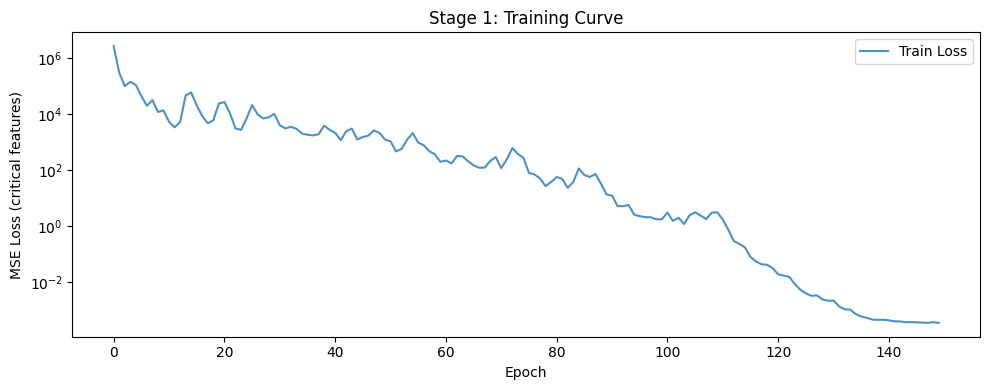

In [26]:
# Plot training curve
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label="Train Loss", alpha=0.8)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss (critical features)")
ax.set_title("Stage 1: Training Curve")
ax.legend()
ax.set_yscale("log")
plt.tight_layout()
plt.show()

## Quick 2016 Evaluation (RMSPE on critical features)

Sanity check using the cached event embeddings for 2016. Builds a rolling-window dataset
over 2016, runs the best Stage 1 checkpoint, recovers prices from log-return predictions
via `p_anchor * exp(cumsum(...))`, and reports RMSPE per critical feature (overall and by
horizon step). This is a cheap proxy for full evaluation — no event-encoder fine-tuning,
no Stage 2 QLoRA — but it shows whether the flat-state Stage 1 model actually tracks 2016
prices out of sample.

In [27]:
# Build a 2016 rolling-window dataset. Start slightly before 2016-01-01 so the
# first sample's horizon begins in early January (the dataset needs `lookback`
# days of context before the first forecast).
eval_ds = CommodityEventDataset(
    deltas_df, market_df, cfg,
    start_date="2015-12-14",
    end_date="2016-12-31",
    embeddings_by_date=embeddings_by_date,
)
eval_loader = DataLoader(
    eval_ds, batch_size=cfg.stage1_batch_size, shuffle=False,
    collate_fn=collate_fn, num_workers=0, pin_memory=True,
)

# Reload best Stage 1 checkpoint and run inference.
model.load_state_dict(torch.load("stage1_best.pt", map_location=DEVICE))
model.eval()

pred_deltas_list, true_deltas_list, anchor_list = [], [], []
with torch.no_grad():
    for batch in eval_loader:
        md = batch["market_deltas"].to(DEVICE)
        an = batch["anchor_state"].to(DEVICE)
        ee = batch["event_embeds"].to(DEVICE)
        em = batch["event_mask"].to(DEVICE)
        pred, _ = model(md, an, ee, em, None)
        pred_deltas_list.append(pred.cpu())
        true_deltas_list.append(batch["target_deltas"])
        anchor_list.append(batch["anchor_state"])

pred_deltas = torch.cat(pred_deltas_list).numpy()   # (N, H, F) predicted log returns
true_deltas = torch.cat(true_deltas_list).numpy()   # (N, H, F) actual log returns
anchors     = torch.cat(anchor_list).numpy()        # (N, F) raw prices on anchor day
print(f"Eval samples: {pred_deltas.shape[0]}, horizon={pred_deltas.shape[1]}")

Dataset [2015-12-14 to 2016-12-31]: 365 samples


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Eval samples: 365, horizon=10


In [28]:
# Recover absolute prices from the log-return predictions and compute RMSPE.
# p[t] = p_anchor * exp(cumsum(log_returns[:t+1])). Valid for the critical
# features because they all live in `log_cols` (not diff_cols).
pred_prices = anchors[:, None, :] * np.exp(np.cumsum(pred_deltas, axis=1))  # (N, H, F)
true_prices = anchors[:, None, :] * np.exp(np.cumsum(true_deltas, axis=1))  # (N, H, F)

pct_err = (pred_prices - true_prices) / true_prices                          # (N, H, F)
rmspe_overall = np.sqrt(np.mean(pct_err ** 2, axis=(0, 1))) * 100            # (F,)
rmspe_by_step = np.sqrt(np.mean(pct_err ** 2, axis=0))       * 100           # (H, F)

print("RMSPE on 2016 (averaged over all samples and horizon steps):")
print("-" * 55)
for feat, idx in zip(cfg.critical_features, critical_indices):
    short = feat.replace("YF_Price_", "")
    print(f"  {short:25s}  {rmspe_overall[idx]:6.2f}%")

print("\nRMSPE by horizon step (%):")
header = "  step " + " ".join(
    f"{f.replace('YF_Price_', ''):>10s}" for f in cfg.critical_features
)
print(header)
print("  " + "-" * (len(header) - 2))
for h in range(cfg.horizon):
    row = f"  {h+1:4d} " + " ".join(
        f"{rmspe_by_step[h, idx]:10.2f}" for idx in critical_indices
    )
    print(row)

RMSPE on 2016 (averaged over all samples and horizon steps):
-------------------------------------------------------
  Crude Oil (WTI)             20.94%
  Crude Oil (Brent)            9.56%
  Gold                         6.25%
  Natural Gas                 23.99%
  Silver                      14.76%
  Copper                       5.93%

RMSPE by horizon step (%):
  step Crude Oil (WTI) Crude Oil (Brent)       Gold Natural Gas     Silver     Copper
  -----------------------------------------------------------------------------------
     1       5.07       5.64       2.40       6.24       3.20       2.74
     2       8.60       4.66       2.53       9.80       5.63       3.74
     3      15.27       4.58       3.48      13.82       6.82       5.62
     4      21.63       7.10       5.44      15.59      11.82       4.84
     5      21.55       8.00       8.09      17.47      11.89       6.65
     6      21.63      11.77       5.70      17.07      12.65       6.90
     7      22.66      